In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_json("./data/cleaned/clean_dataframe.json")

rows_to_Int64 = ["postcode", "price", "build_year", "bedroom_count", "livable_surface", "total_surface", "garage", "terrace", "swimming_pool", "energy_consumption_kWh/m2/year", "preschool_distance_m", "train_station_distance_m", "supermarket_distance_m"]

for row in rows_to_Int64:
    if df[row].dtype == "float64":
        df[row] = df[row].astype("Int64")

#other option: pd.read_json(file_path, dtype={"postcode": "Int64", ...})
df["price"] = df["price"] // 100

In [3]:
df.sort_values(by='price', inplace=True) # not necessary because groupby + median does the sorting before finding the median
df.head()

,property_type,property_id,postcode,city,province,address,latitude,longitude,price,property_state,...,total_surface,garage,terrace,energy_consumption_kWh/m2/year,swimming_pool,preschool_distance_m,train_station_distance_m,supermarket_distance_m,nearest_city,nearest_city_distance_km
11573,house,VBB54282,6700,Arlon,luxembourg,NaN,49.683333,5.816667,2500,Excellent,...,34508,1,1,47,<NA>,92,766,315,Liege,108.34
5054,apartment,RWC42370,8400,Oostende,west-flanders,Troonstraat 184,51.218258,2.887066,3048,Excellent,...,<NA>,1,1,<NA>,<NA>,695,3400,151,Bruges,23.54
10194,house,VBE09670,4100,Boncelles,liege,rue Nicolas Fossoul 92,50.575840,5.538864,5000,NaN,...,152,1,0,516,<NA>,446,4600,1400,Liege,8.08
8210,house,VBE29000,6464,Baileux,hainaut,Domaine de la Longue Taille 169,49.994179,4.316405,19900,Normal,...,200,<NA>,0,<NA>,0,3800,<NA>,7200,Charleroi,47.22
8260,house,VBE27312,7090,Hennuy&#xE8;res,hainaut,NaN,50.638430,4.169600,20000,NaN,...,565,1,0,583,<NA>,527,1900,2400,Brussels,26.41


In [4]:
for col in ["terrace", "garage", "swimming_pool"]:
    print(f"{col} : {df[col].nunique()} unique -> \n  {df[col].unique()}\n")

terrace : 2 unique -> 
  <IntegerArray>
[1, 0, <NA>]
Length: 3, dtype: Int64

garage : 1 unique -> 
  <IntegerArray>
[1, <NA>]
Length: 2, dtype: Int64

swimming_pool : 2 unique -> 
  <IntegerArray>
[<NA>, 0, 1]
Length: 3, dtype: Int64



In [5]:
aparts = df[df["property_type"] == "apartment"]
houses = df[df["property_type"] == "house"]
print(aparts.shape)
print(houses.shape)
print(houses.info())
garage_appart = aparts.loc[:,["garage"]]
print(garage_appart.info())
#res: 5220 aparts, of which 1744 with garage

(5220, 23)
(9488, 23)
<class 'pandas.DataFrame'>
Index: 9488 entries, 11573 to 7169
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   property_type                   9488 non-null   str    
 1   property_id                     9488 non-null   str    
 2   postcode                        9488 non-null   int64  
 3   city                            9488 non-null   str    
 4   province                        9488 non-null   str    
 5   address                         7038 non-null   str    
 6   latitude                        9488 non-null   float64
 7   longitude                       9488 non-null   float64
 8   price                           9488 non-null   int64  
 9   property_state                  7367 non-null   str    
 10  build_year                      5596 non-null   Int64  
 11  bedroom_count                   9342 non-null   Int64  
 12  livable_surface         

In [6]:
price_by_province = df.groupby('province', observed=True)["price"].agg(["count", "median", "mean"])
print(price_by_province)

                count    median           mean
province                                      
antwerp          1956  295000.0  417861.534765
brabant-wallon   1298  395000.0  570037.543914
brussels         1600  390000.0  768523.850000
east-flanders     769  359000.0  461529.868661
hainaut          1932  200000.0  340235.266046
liege            1846  199000.0  322352.040628
limburg           721  290000.0  368902.957004
luxembourg       1023  295000.0  340807.823069
namur            1020  196500.0  315766.690196
vlaams-brabant   1471  549500.0  628243.744392
west-flanders    1072  279000.0  447246.247201


In [7]:
# ── Colour palette we'll reuse ────────────────────────────────────────────────
BLUE   = '#2166ac'
ORANGE = '#d6604d'
GREEN  = '#4dac26'
GREY   = '#878787'
PALETTE = [BLUE, ORANGE, GREEN, '#9970ab', '#bf812d']

In [8]:
# ── Shared style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})

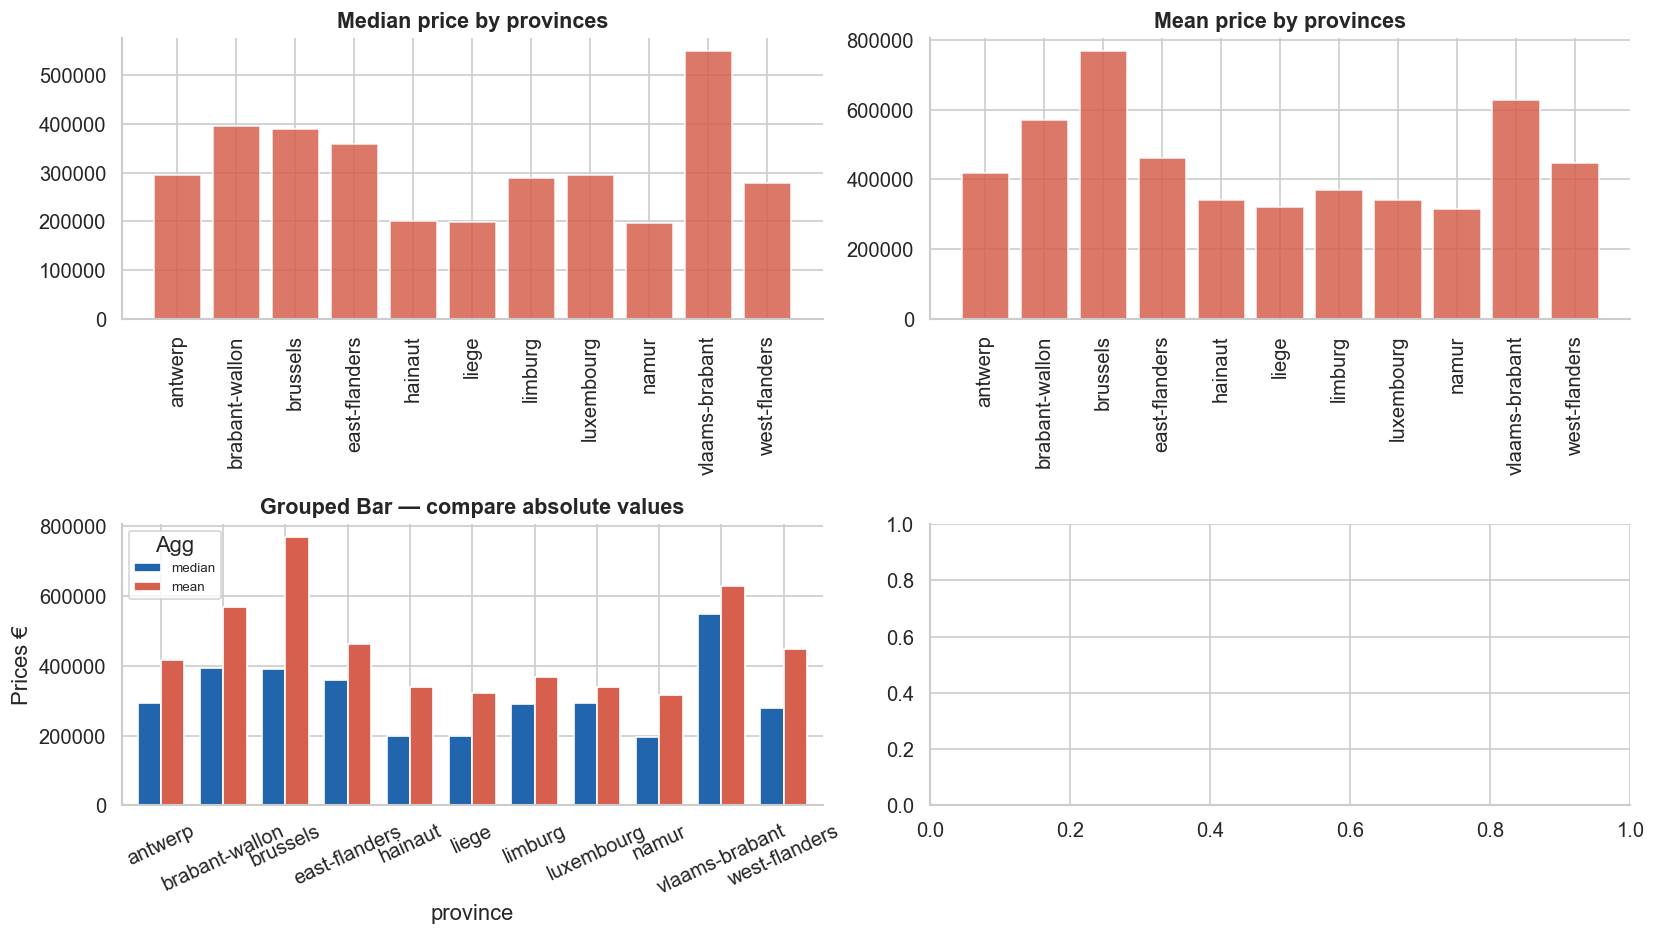

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# bar() creates a bar chart, cats are the categories on x-axis, vals are the heights of the bars
cats = price_by_province.index
vals = price_by_province["median"]
axes[0, 0].bar(cats, vals, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Median price by provinces')
axes[0, 0].tick_params(axis='x', rotation=90)

# bar() creates a bar chart, cats are the categories on x-axis, vals are the heights of the bars
cats = price_by_province.index
vals = price_by_province["mean"]
axes[0, 1].bar(cats, vals, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Mean price by provinces')
axes[0, 1].tick_params(axis='x', rotation=90)

# Group bar
price_by_province[["median", "mean"]].plot(kind='bar', ax=axes[1, 0], color=PALETTE, edgecolor='white',
               width=0.75, rot=25)
axes[1, 0].set_title('Grouped Bar — compare absolute values')
axes[1, 0].set_ylabel('Prices €')
axes[1, 0].legend(title='Agg', fontsize=8)

plt.tight_layout()
#plt.savefig('filepath', dpi=130, bbox_inches='tight')


In [10]:
#n_rows = len(df.index)
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
houses_nan_percentages = (houses.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
aparts_nan_percentages = (aparts.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)


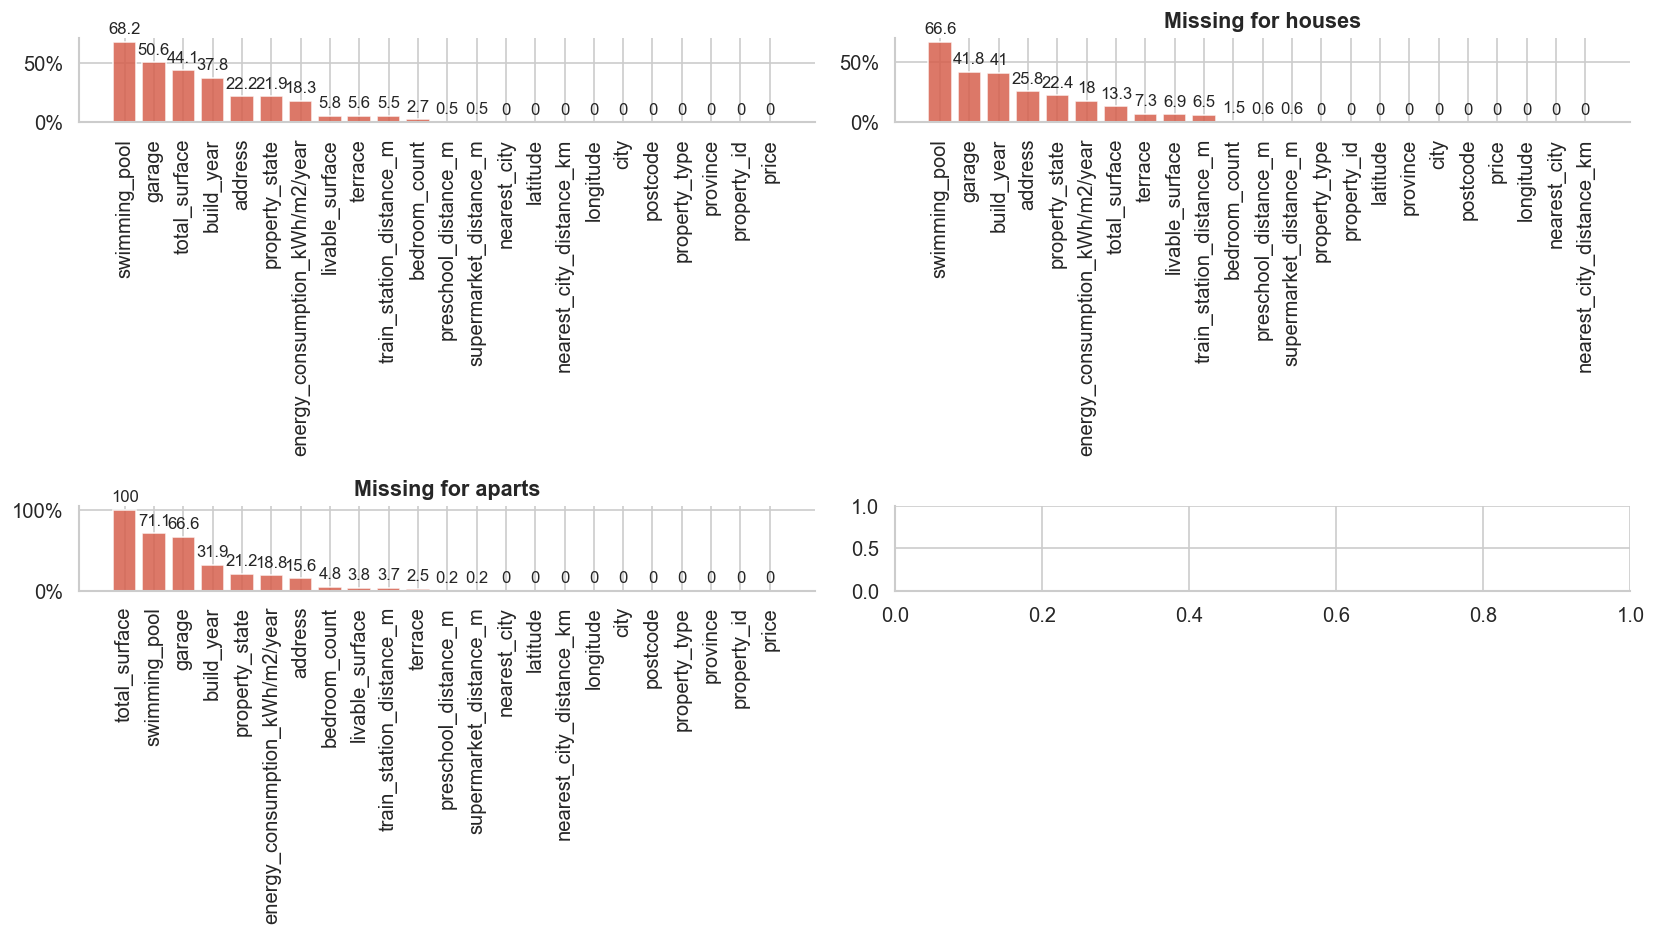

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

bars1 = axes[0,0].bar(nan_percentages.index, nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[0,0].bar_label(bars1, padding=3, fontsize=10)
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,0].tick_params(axis='x', rotation=90)

bars1 = axes[0,1].bar(houses_nan_percentages.index, houses_nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[0,1].bar_label(bars1, padding=3, fontsize=10)
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,1].tick_params(axis='x', rotation=90)
axes[0,1].set_title('Missing for houses')

bars1 = axes[1,0].bar(aparts_nan_percentages.index, aparts_nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[1,0].bar_label(bars1, padding=3, fontsize=10)
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_title('Missing for aparts')

plt.tight_layout()


We should fill in missing values in swimming_pool and garage with 0

In [12]:
df.fillna(value={'garage': 0, 'swimming_pool': 0}, inplace=True)
for col in ["garage", "swimming_pool"]:
    print(f"{col} : {df[col].nunique()} unique -> \n  {df[col].unique()}\n")
    print(f"YES : {(df[col].mean() * 100):.2f} %\n")

garage : 2 unique -> 
  <IntegerArray>
[1, 0]
Length: 2, dtype: Int64

YES : 49.40 %

swimming_pool : 2 unique -> 
  <IntegerArray>
[0, 1]
Length: 2, dtype: Int64

YES : 5.30 %



In [13]:
aparts = df[df["property_type"] == "apartment"]
houses = df[df["property_type"] == "house"]

In [14]:
numerical = df[['price', 'livable_surface', 'total_surface', 'bedroom_count', 'swimming_pool', 'build_year', "energy_consumption_kWh/m2/year", 'nearest_city_distance_km', "preschool_distance_m", "train_station_distance_m", "supermarket_distance_m"]]
#should change property_state to numerical values??

In [15]:
numerical['nearest_city_distance_km'] = numerical['nearest_city_distance_km'].round().astype("Int64")
numerical.info()

<class 'pandas.DataFrame'>
Index: 14708 entries, 11573 to 7169
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   price                           14708 non-null  int64
 1   livable_surface                 13853 non-null  Int64
 2   total_surface                   8224 non-null   Int64
 3   bedroom_count                   14312 non-null  Int64
 4   swimming_pool                   14708 non-null  Int64
 5   build_year                      9153 non-null   Int64
 6   energy_consumption_kWh/m2/year  12021 non-null  Int64
 7   nearest_city_distance_km        14707 non-null  Int64
 8   preschool_distance_m            14641 non-null  Int64
 9   train_station_distance_m        13898 non-null  Int64
 10  supermarket_distance_m          14641 non-null  Int64
dtypes: Int64(10), int64(1)
memory usage: 1.5 MB


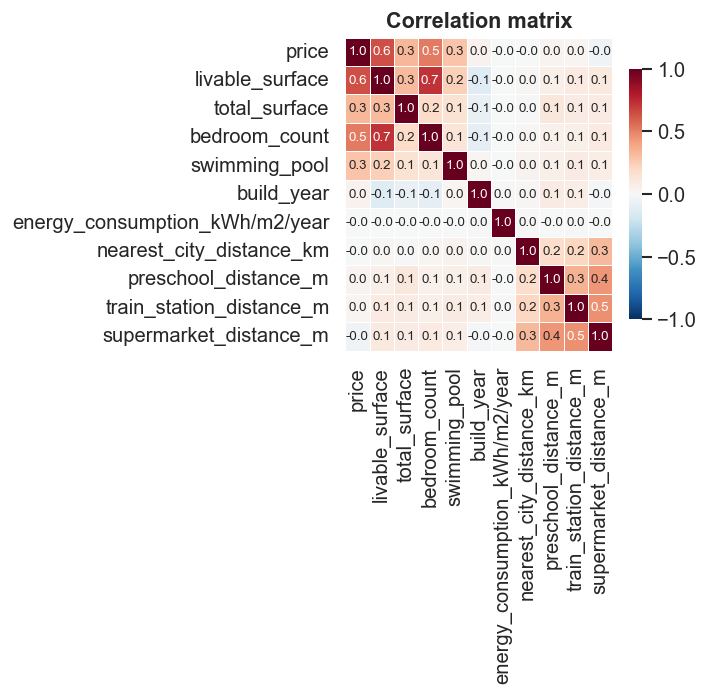

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

corr = numerical.corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix')
plt.tight_layout()

In [17]:
print(f"property_state : {df['property_state'].nunique()} unique -> \n  {df['property_state'].unique()}\n")

property_state : 9 unique -> 
  <StringArray>
[         'Excellent',                  nan,             'Normal',
        'To demolish',    'To be renovated',                'New',
         'To restore',        'To renovate',    'Fully renovated',
 'Under construction']
Length: 10, dtype: str



In [18]:
property_state = df.groupby('property_state', observed=True)["price"].agg(["count", "median", "mean"])

/var/folders/km/ghx8xx4s4q77h_htj648vz280000gn/T/ipykernel_60018/2695447252.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend(title='Agg', fontsize=8)


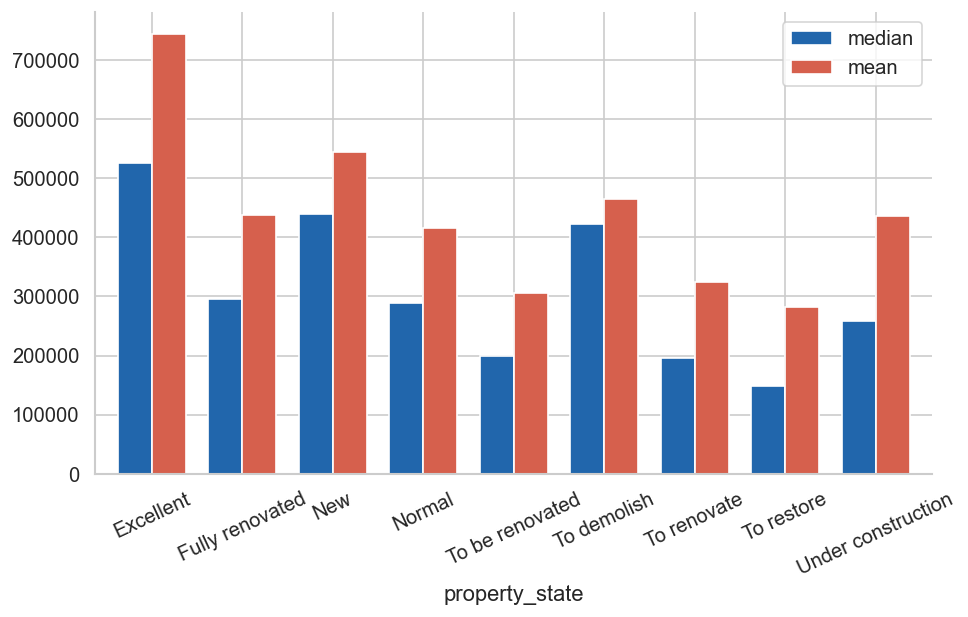

In [19]:
property_state[["median", "mean"]].plot(kind='bar', color=PALETTE, edgecolor='white',
               width=0.75, rot=25)
axes[1, 0].set_title('Grouped Bar — compare absolute values')
axes[1, 0].set_ylabel('Prices €')
axes[1, 0].legend(title='Agg', fontsize=8)

In [ ]:
states_dict = {"Excellent": 7, "Fully renovated": 5, "New": 6, "Normal": 4, "To be renovated": 2, "To demolish": 0, "To renovate": 2, "To restore": 1, "Under construction": 3}
df['property_state'] = df['property_state'].map(states_dict)

print(df.info())
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
print(nan_percentages.loc['property_state'])


In [23]:
df['property_state'] = df['property_state'].astype(pd.Int64Dtype())
print(df.info())
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
print(nan_percentages.loc['property_state'])

<class 'pandas.DataFrame'>
Index: 14708 entries, 11573 to 7169
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   property_type                   14708 non-null  str    
 1   property_id                     14708 non-null  str    
 2   postcode                        14708 non-null  int64  
 3   city                            14708 non-null  str    
 4   province                        14708 non-null  str    
 5   address                         11443 non-null  str    
 6   latitude                        14707 non-null  float64
 7   longitude                       14707 non-null  float64
 8   price                           14708 non-null  int64  
 9   property_state                  11482 non-null  Int64  
 10  build_year                      9153 non-null   Int64  
 11  bedroom_count                   14312 non-null  Int64  
 12  livable_surface                 13853 non-nul

In [25]:
numerical['property_state'] = df['property_state']

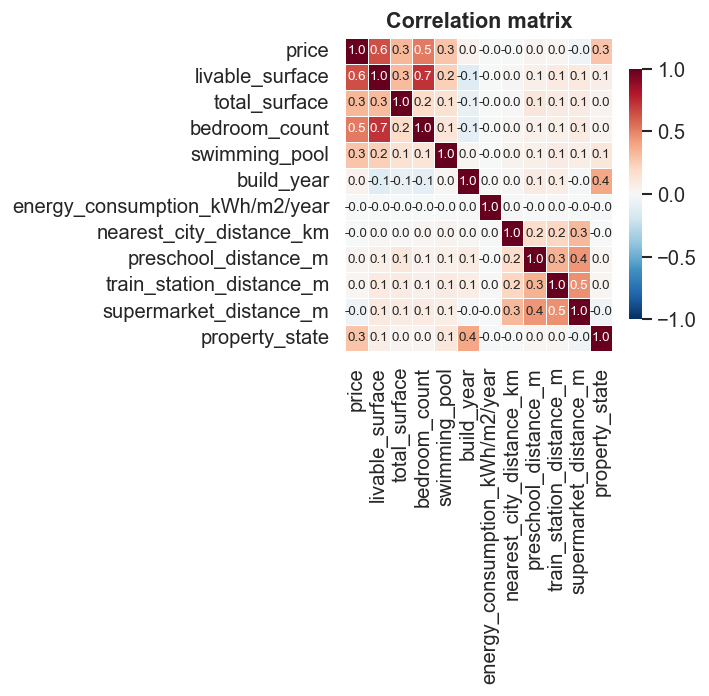

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))

corr = numerical.corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix')
plt.tight_layout()